# Option 2: Stock Price Value Prediction - Regression

## Objective
Predict next day's stock price value using regression models

## Models Tested
- Linear Regression
- Decision Tree Regressor
- XGBoost Regressor
- TabNet Regressor
- Neural Network (TensorFlow)
- LSTM (Kaggle-style close-price sequence model, multi-stock)
- GRU (Kaggle-style close-price sequence model, multi-stock)

In [58]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost tensorflow kagglehub pytorch-tabnet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                            mean_absolute_percentage_error)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import kagglehub, os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

cwd = Path.cwd()
TASK_FOLDER = '02_stock_price_regression'
if cwd.name == 'implementation':
    task_root = cwd.parent
elif cwd.name == TASK_FOLDER:
    task_root = cwd
elif (cwd / TASK_FOLDER).exists():
    task_root = cwd / TASK_FOLDER
else:
    task_root = cwd

GRAPH_DIR = task_root / 'graph'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("[OK] All libraries loaded successfully")
print(f"[OK] Graph output folder: {GRAPH_DIR}")

Note: you may need to restart the kernel to use updated packages.
[OK] All libraries loaded successfully
[OK] Graph output folder: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\02_stock_price_regression\graph


## Step 1: Data Loading & Exploration

In [59]:
# Download S&P 500 dataset
path = kagglehub.dataset_download("camnugent/sandp500")
files = os.listdir(path)
csv_file = [f for f in files if f.endswith(".csv")][0]
data = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset Shape: {data.shape}")
print(f"\nPrice Range: ${data['close'].min():.2f} - ${data['close'].max():.2f}")
print(f"Average Price: ${data['close'].mean():.2f}")
print(f"\nDate Range: {data['date'].min()} to {data['date'].max()}")

Dataset Shape: (619040, 7)

Price Range: $1.59 - $2049.00
Average Price: $83.04

Date Range: 2013-02-08 to 2018-02-07


## Step 2: Feature Engineering for Regression

In [60]:
# Select requested stocks and guarantee at least 5 symbols for project requirements
MIN_STOCKS = 5
requested_stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
all_symbols = data['Name'].value_counts().index.tolist()

# Keep requested stocks that exist in the dataset (preserve requested order)
available_requested = [s for s in requested_stocks if s in set(all_symbols)]
missing_stocks = [s for s in requested_stocks if s not in set(all_symbols)]

# Backfill with additional available symbols if requested set has fewer than MIN_STOCKS
needed = max(0, MIN_STOCKS - len(available_requested))
backup_stocks = [s for s in all_symbols if s not in available_requested][:needed]
top_stocks = available_requested + backup_stocks

if missing_stocks:
    print(f"[WARN] Missing requested tickers in dataset: {', '.join(missing_stocks)}")
if backup_stocks:
    print(f"[INFO] Added backup tickers to meet minimum {MIN_STOCKS}: {', '.join(backup_stocks)}")
if len(top_stocks) < MIN_STOCKS:
    print(f"[WARN] Dataset only provides {len(top_stocks)} unique symbols after filtering")

data_filtered = data[data['Name'].isin(top_stocks)].copy()
data_filtered = data_filtered.sort_values(['Name', 'date']).reset_index(drop=True)

def create_regression_features(stock_data):
    """Create features for stock price regression"""
    stock_data = stock_data.sort_values('date').reset_index(drop=True)
    
    # Target: Tomorrow's close price
    stock_data['target'] = stock_data['close'].shift(-1)
    
    # Price features
    stock_data['price_range'] = (stock_data['high'] - stock_data['low']) / stock_data['open']
    stock_data['close_open_diff'] = (stock_data['close'] - stock_data['open']) / stock_data['open']
    stock_data['high_low_ratio'] = stock_data['high'] / stock_data['low']
    
    # Returns
    stock_data['daily_return'] = stock_data['close'].pct_change()
    stock_data['lag_return_1'] = stock_data['daily_return'].shift(1)
    stock_data['lag_return_5'] = stock_data['close'].pct_change(5)
    
    # Volume features
    stock_data['volume_norm'] = stock_data['volume'] / stock_data['volume'].rolling(20).mean()
    stock_data['volume_trend'] = (stock_data['volume'] - stock_data['volume'].rolling(20).mean()) / stock_data['volume'].rolling(20).mean()
    
    # Moving averages
    stock_data['close_ma5'] = stock_data['close'].rolling(5).mean()
    stock_data['close_ma20'] = stock_data['close'].rolling(20).mean()
    stock_data['close_ma50'] = stock_data['close'].rolling(50).mean()
    
    # Price momentum
    stock_data['momentum_5'] = (stock_data['close'] - stock_data['close'].shift(5)) / stock_data['close'].shift(5)
    stock_data['momentum_20'] = (stock_data['close'] - stock_data['close'].shift(20)) / stock_data['close'].shift(20)
    
    # Volatility
    stock_data['volatility_20'] = stock_data['daily_return'].rolling(20).std()
    stock_data['volatility_60'] = stock_data['daily_return'].rolling(60).std()
    
    # RSI
    delta = stock_data['daily_return'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    stock_data['rsi'] = 100 - (100 / (1 + rs))
    
    # ADX-like trend strength
    stock_data['price_strength'] = abs(stock_data['close'] - stock_data['close'].shift(5)) / stock_data['close'].rolling(20).std()
    
    return stock_data

# Apply feature engineering
data_features = pd.concat([create_regression_features(data_filtered[data_filtered['Name'] == stock])
                           for stock in top_stocks], ignore_index=True)
data_features = data_features.dropna()

print(f"[OK] Using tickers ({len(top_stocks)}): {', '.join(top_stocks)}")
print(f"[OK] Features created. Dataset shape: {data_features.shape}")
print(f"\nTarget (Next Day Price) Statistics:")
print(data_features['target'].describe())

[OK] Using tickers (5): AAPL, MSFT, GOOGL, AMZN, NVDA
[OK] Features created. Dataset shape: (5990, 25)

Target (Next Day Price) Statistics:
count    5990.000000
mean      302.293410
std       320.701699
min        13.899000
25%        52.170000
50%       118.995000
75%       545.740000
max      1450.890000
Name: target, dtype: float64


## Step 3: Data Visualization

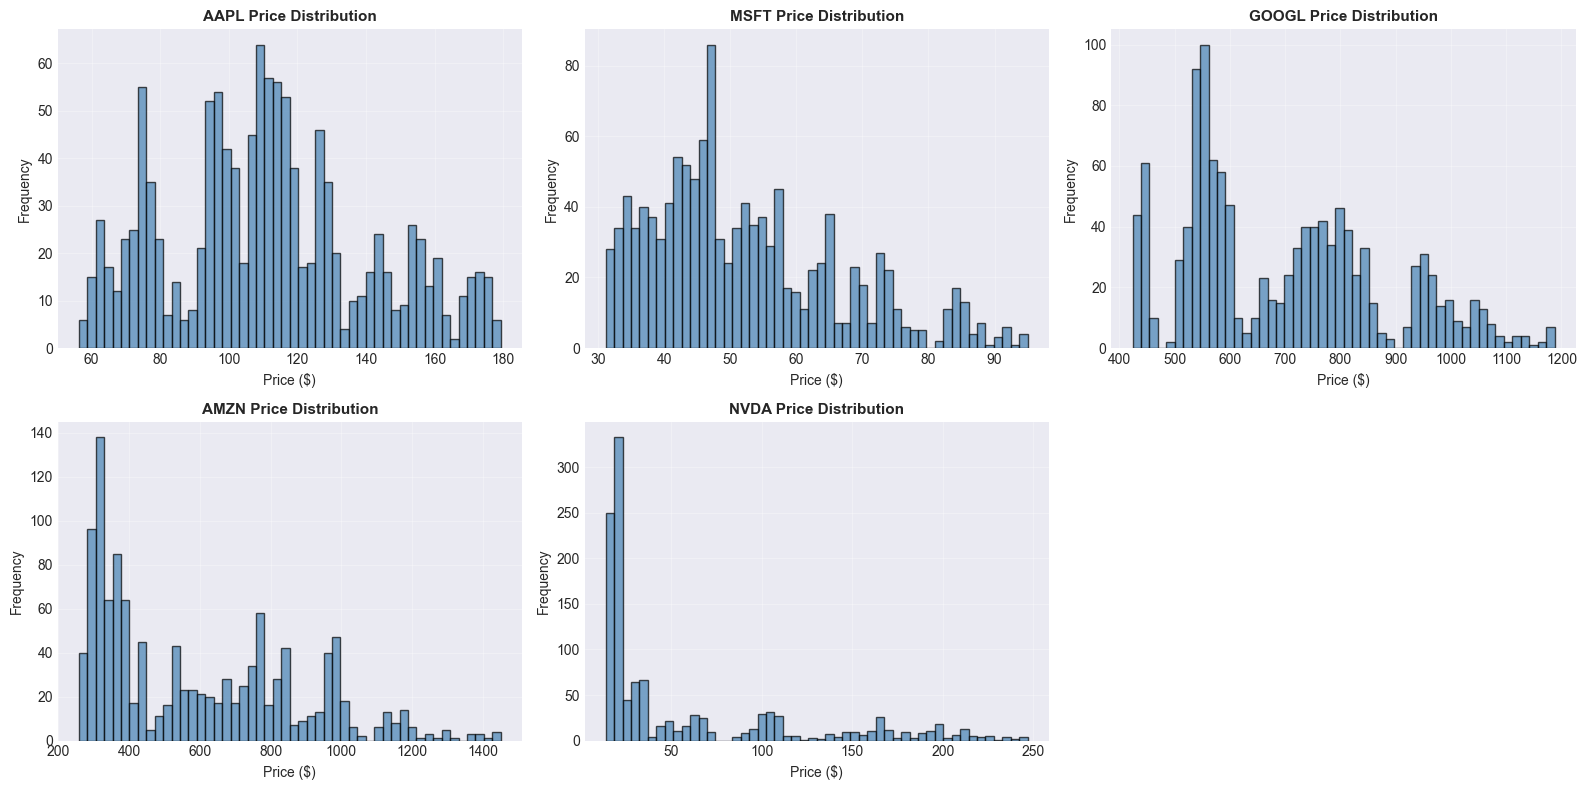

[OK] Saved: 01_price_distributions.png


In [61]:
# Price distributions by stock
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for idx, stock in enumerate(top_stocks):
    # Use a same-dataframe filter to avoid index alignment issues.
    stock_prices = data_features.loc[data_features['Name'] == stock, 'close'].dropna()
    if stock_prices.empty:
        stock_prices = data_filtered.loc[data_filtered['Name'] == stock, 'close'].dropna()

    if stock_prices.empty:
        axes[idx].text(0.5, 0.5, f'No data for {stock}', ha='center', va='center', fontsize=11)
        axes[idx].set_title(f'{stock} Price Distribution', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Price ($)')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)
        continue

    axes[idx].hist(stock_prices, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{stock} Price Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Price ($)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Hide any remaining unused subplot panels
for j in range(len(top_stocks), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '01_price_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 01_price_distributions.png")

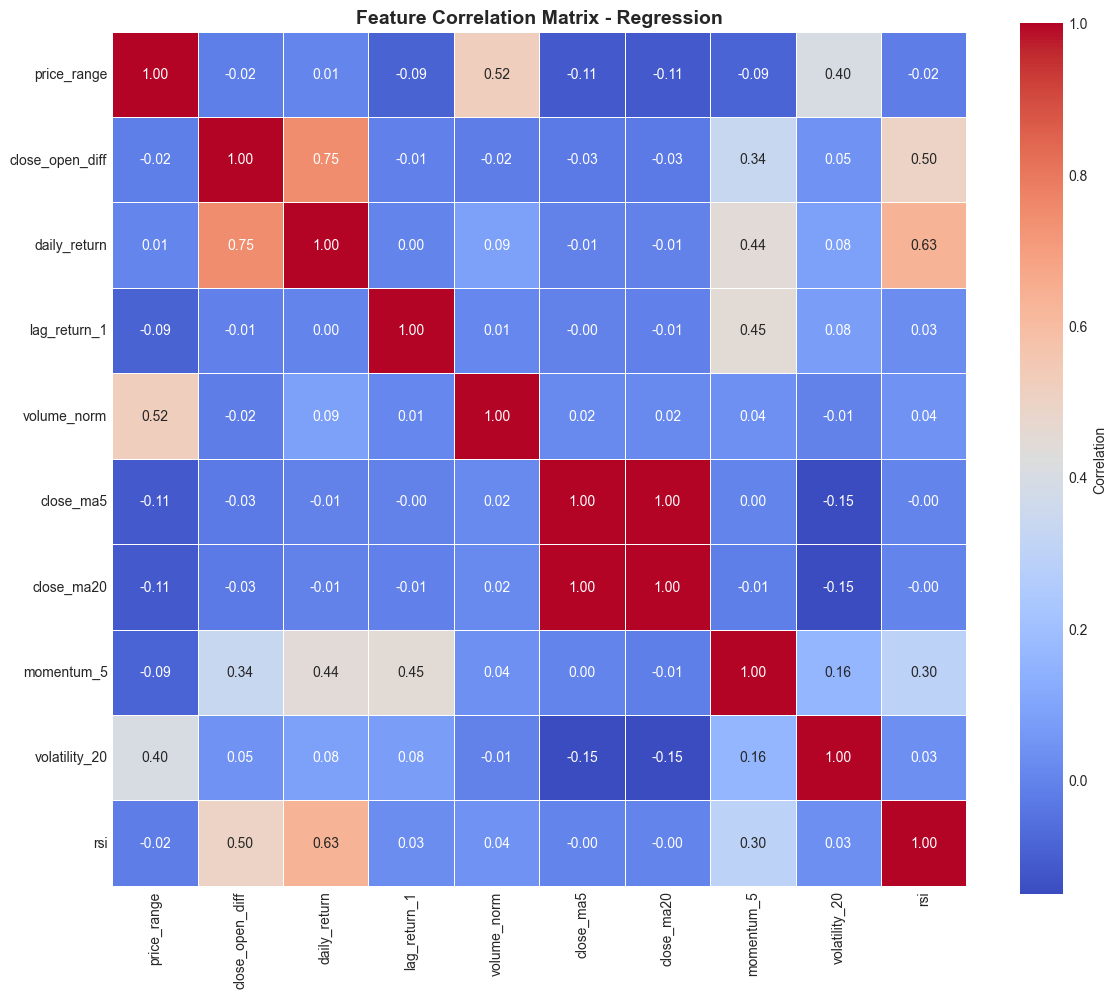

[OK] Saved: 02_feature_correlation_regression.png


In [62]:
# Feature correlation for regression
feature_cols = ['price_range', 'close_open_diff', 'daily_return', 'lag_return_1',
                'volume_norm', 'close_ma5', 'close_ma20', 'momentum_5',
                'volatility_20', 'rsi']

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = data_features[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            cbar_kws={'label': 'Correlation'}, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix - Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '02_feature_correlation_regression.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 02_feature_correlation_regression.png")

## Step 4: Data Preparation

In [63]:
# Prepare data
X = data_features[feature_cols].copy()
y = data_features['target'].copy()
X = X.fillna(X.mean())

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale targets for neural network
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")
print(f"\nTarget price range (Train): {y_train.min():.2f} - {y_train.max():.2f}")
print(f"Target price range (Test):  {y_test.min():.2f} - {y_test.max():.2f}")

Training set: 4792 samples | Test set: 1198 samples

Target price range (Train): 13.90 - 1437.82
Target price range (Test):  14.09 - 1450.89


## Step 5: Model Training

In [64]:
# Define regression models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    results[name] = {
        'model': model,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }

    print(f"MAE:   ${mae:.4f}")
    print(f"RMSE:  ${rmse:.4f}")
    print(f"MAPE:  {mape:.4f} ({mape*100:.2f}%)")
    print(f"R^2:   {r2:.4f}")
    print(f"CV R^2 (mean): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Train TabNet next to XGBoost for tabular deep learning comparison
print(f"\n{'='*50}")
print("Training TabNet...")
print(f"{'='*50}")

X_train_tab, X_val_tab, y_train_tab, y_val_tab = train_test_split(
    X_train_scaled.astype(np.float32),
    y_train.values.reshape(-1, 1).astype(np.float32),
    test_size=0.2,
    random_state=42
)

X_test_tab = X_test_scaled.astype(np.float32)
y_test_tab = y_test.values.reshape(-1, 1).astype(np.float32)

tabnet_model = TabNetRegressor(seed=42, verbose=0)
tabnet_model.fit(
    X_train=X_train_tab,
    y_train=y_train_tab,
    eval_set=[(X_val_tab, y_val_tab)],
    eval_name=['val'],
    eval_metric=['mae'],
    max_epochs=150,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

y_pred_tabnet = tabnet_model.predict(X_test_tab).ravel()

mae_tab = mean_absolute_error(y_test, y_pred_tabnet)
rmse_tab = np.sqrt(mean_squared_error(y_test, y_pred_tabnet))
mape_tab = mean_absolute_percentage_error(y_test, y_pred_tabnet)
r2_tab = r2_score(y_test, y_pred_tabnet)

results['TabNet'] = {
    'model': tabnet_model,
    'mae': mae_tab,
    'rmse': rmse_tab,
    'mape': mape_tab,
    'r2': r2_tab,
    'cv_mean': None,
    'cv_std': None,
    'y_pred': y_pred_tabnet
}

print(f"MAE:   ${mae_tab:.4f}")
print(f"RMSE:  ${rmse_tab:.4f}")
print(f"MAPE:  {mape_tab:.4f} ({mape_tab*100:.2f}%)")
print(f"R^2:   {r2_tab:.4f}")

print("\n[OK] Traditional models + TabNet trained!")


Training Linear Regression...
MAE:   $5.0849
RMSE:  $8.4799
MAPE:  0.0420 (4.20%)
R^2:   0.9992
CV R^2 (mean): 0.9993 (+/- 0.0001)

Training Decision Tree...
MAE:   $5.3512
RMSE:  $10.6675
MAPE:  0.0193 (1.93%)
R^2:   0.9988
CV R^2 (mean): 0.9990 (+/- 0.0001)

Training XGBoost...
MAE:   $4.2092
RMSE:  $8.9069
MAPE:  0.0160 (1.60%)
R^2:   0.9992
CV R^2 (mean): 0.9993 (+/- 0.0001)

Training TabNet...

Early stopping occurred at epoch 63 with best_epoch = 43 and best_val_mae = 8.4068
MAE:   $8.9415
RMSE:  $12.8636
MAPE:  0.0661 (6.61%)
R^2:   0.9983

[OK] Traditional models + TabNet trained!


In [65]:
# Neural Network Model
print("\n" + "="*50)
print("Training Neural Network...")
print("="*50)

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

nn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = nn_model.fit(
    X_train_scaled, y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Predict
y_pred_nn_scaled = nn_model.predict(X_test_scaled, verbose=0)
y_pred_nn = y_scaler.inverse_transform(y_pred_nn_scaled).ravel()

# Calculate metrics
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mape_nn = mean_absolute_percentage_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

results['Neural Network'] = {
    'model': nn_model,
    'mae': mae_nn,
    'rmse': rmse_nn,
    'mape': mape_nn,
    'r2': r2_nn,
    'cv_mean': None,
    'cv_std': None,
    'y_pred': y_pred_nn,
    'history': history
}

print(f"MAE:   ${mae_nn:.4f}")
print(f"RMSE:  ${rmse_nn:.4f}")
print(f"MAPE:  {mape_nn:.4f} ({mape_nn*100:.2f}%)")
print(f"R^2:   {r2_nn:.4f}")

print("\n[OK] All models trained successfully!")


Training Neural Network...
MAE:   $50.9852
RMSE:  $61.6885
MAPE:  0.7845 (78.45%)
R^2:   0.9601

[OK] All models trained successfully!


In [66]:
# Sequence Models (Kaggle-style): LSTM + GRU on close-price windows
print("\n" + "="*50)
print("Training sequence models (LSTM + GRU, Kaggle-style close sequences)...")
print("="*50)

LOOKBACK = 60

def build_close_sequences_for_stock(stock_df, lookback=60):
    stock_df = stock_df.sort_values('date').reset_index(drop=True)
    close_vals = stock_df['close'].values.reshape(-1, 1).astype(np.float32)

    if len(close_vals) <= lookback + 5:
        return None

    split_idx = int(len(close_vals) * 0.8)
    train_close = close_vals[:split_idx]

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(train_close)
    close_scaled = scaler.transform(close_vals).ravel()

    X_train, y_train = [], []
    X_test, y_test = [], []

    for i in range(lookback, split_idx):
        X_train.append(close_scaled[i - lookback:i])
        y_train.append(close_scaled[i])

    for i in range(split_idx, len(close_scaled)):
        X_test.append(close_scaled[i - lookback:i])
        y_test.append(close_scaled[i])

    if len(X_train) == 0 or len(X_test) == 0:
        return None

    X_train = np.array(X_train, dtype=np.float32).reshape(-1, lookback, 1)
    y_train = np.array(y_train, dtype=np.float32)
    X_test = np.array(X_test, dtype=np.float32).reshape(-1, lookback, 1)
    y_test = np.array(y_test, dtype=np.float32)

    return X_train, y_train, X_test, y_test, scaler

# Build pooled sequences from at least 5 stocks while preserving per-stock scaling
X_train_seq_all, y_train_seq_all = [], []
X_test_seq_all, y_test_seq_all = [], []
test_scalers = []
train_stock_count = 0

for stock in top_stocks:
    stock_df = data_features[data_features['Name'] == stock][['date', 'close']].copy()
    seq_data = build_close_sequences_for_stock(stock_df, lookback=LOOKBACK)
    if seq_data is None:
        continue

    X_tr, y_tr, X_te, y_te, stock_scaler = seq_data
    train_stock_count += 1

    X_train_seq_all.append(X_tr)
    y_train_seq_all.append(y_tr)
    X_test_seq_all.append(X_te)
    y_test_seq_all.append(y_te)
    test_scalers.extend([stock_scaler] * len(y_te))

if train_stock_count == 0:
    print("[WARN] Sequence models skipped: insufficient data after sequence construction")
else:
    X_train_seq = np.concatenate(X_train_seq_all, axis=0)
    y_train_seq = np.concatenate(y_train_seq_all, axis=0)
    X_test_seq = np.concatenate(X_test_seq_all, axis=0)
    y_test_seq = np.concatenate(y_test_seq_all, axis=0)

    print(f"[OK] Stocks used for sequence models: {train_stock_count}")
    print(f"[OK] Sequence train shape: {X_train_seq.shape}")
    print(f"[OK] Sequence test shape:  {X_test_seq.shape}")

    def inverse_by_scaler(values_scaled, scalers):
        values = np.empty(len(values_scaled), dtype=np.float32)
        for i, (val, sc) in enumerate(zip(values_scaled, scalers)):
            values[i] = sc.inverse_transform(np.array([[val]], dtype=np.float32))[0, 0]
        return values

    def train_sequence_model(model_name, model_builder, epochs=40, batch_size=64, use_validation=True):
        print(f"\n{'='*50}")
        print(f"Training {model_name}...")
        print(f"{'='*50}")

        model = model_builder()
        model.compile(optimizer='adam', loss='mean_squared_error')

        if use_validation:
            early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
            history = model.fit(
                X_train_seq, y_train_seq,
                epochs=epochs,
                batch_size=batch_size,
                validation_split=0.2,
                callbacks=[early_stop],
                verbose=0
            )
        else:
            history = model.fit(
                X_train_seq, y_train_seq,
                batch_size=batch_size,
                epochs=epochs,
                verbose=0
            )

        y_pred_scaled = model.predict(X_test_seq, verbose=0).ravel()
        y_pred = inverse_by_scaler(y_pred_scaled, test_scalers)
        y_true = inverse_by_scaler(y_test_seq, test_scalers)

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = mean_absolute_percentage_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        results[model_name] = {
            'model': model,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'r2': r2,
            'cv_mean': None,
            'cv_std': None,
            'y_pred': y_pred,
            'y_true': y_true,
            'history': history
        }

        print(f"MAE:   ${mae:.4f}")
        print(f"RMSE:  ${rmse:.4f}")
        print(f"MAPE:  {mape:.4f} ({mape*100:.2f}%)")
        print(f"R^2:   {r2:.4f}")

    # Follow user-requested Kaggle-style LSTM architecture and fit settings
    def build_lstm_model():
        model = Sequential()
        model.add(LSTM(128, return_sequences=True, input_shape=(X_train_seq.shape[1], 1)))
        model.add(LSTM(64, return_sequences=False))
        model.add(Dense(25))
        model.add(Dense(1))
        return model

    def build_gru_model():
        return Sequential([
            GRU(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
            Dropout(0.2),
            GRU(32),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])

    # Exact settings requested for LSTM snippet
    train_sequence_model('LSTM', build_lstm_model, epochs=50, batch_size=64, use_validation=False)

    # Keep GRU as stronger sequence baseline with regularized training
    train_sequence_model('GRU', build_gru_model, epochs=40, batch_size=64, use_validation=True)

    print("\n[OK] Sequence baselines (LSTM + GRU) added to model comparison!")


Training sequence models (LSTM + GRU, Kaggle-style close sequences)...
[OK] Stocks used for sequence models: 5
[OK] Sequence train shape: (4490, 60, 1)
[OK] Sequence test shape:  (1200, 60, 1)

Training LSTM...
MAE:   $4.6877
RMSE:  $9.0637
MAPE:  0.0108 (1.08%)
R^2:   0.9996

Training GRU...
MAE:   $13.9211
RMSE:  $22.7227
MAPE:  0.0293 (2.93%)
R^2:   0.9973

[OK] Sequence baselines (LSTM + GRU) added to model comparison!


## Step 5.1: Optuna Hyperparameter Tuning (Dense NN, LSTM, GRU, XGBoost)

Use Optuna to tune key hyperparameters and compare tuned models against existing baselines.

Note: you may need to restart the kernel to use updated packages.
[INFO] Starting Optuna tuning...
[INFO] N_TRIALS_TABULAR=15, N_TRIALS_SEQUENCE=10

[OK] XGBoost (Optuna) done
Best MAE (val): 4.2927

[OK] Dense NN (Optuna) done
Best MAE (val, scaled): 0.0267

[OK] LSTM (Optuna) done
Best MAE (val, scaled): 0.0104

[OK] GRU (Optuna) done
Best MAE (val, scaled): 0.0080

OPTUNA-TUNED MODEL PERFORMANCE
                         MAE ($)  RMSE ($)  MAPE (%)     R^2
XGBoost (Optuna)          4.2223    8.7826    1.6232  0.9992
Neural Network (Optuna)   8.2581   12.5360    8.7451  0.9984
GRU (Optuna)             10.6848   17.5541    2.2745  0.9984
LSTM (Optuna)            22.4876   35.0265    4.7248  0.9935


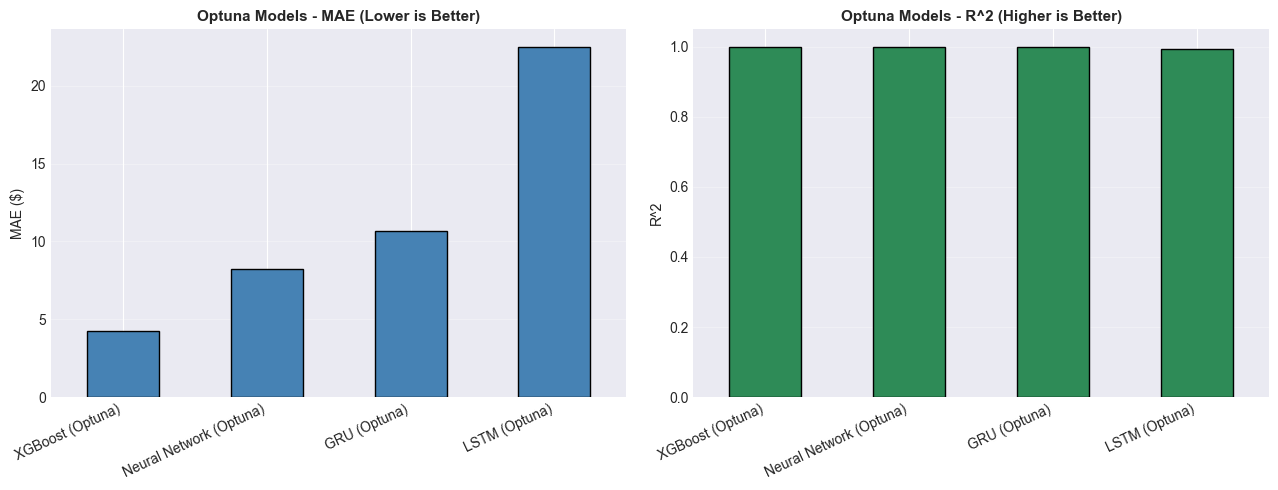

[OK] Saved: 08_optuna_tuned_models.png


In [67]:
%pip install -q optuna

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Optional: reduce Optuna/TensorFlow verbosity
optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.get_logger().setLevel('ERROR')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Trial counts (increase for stronger search, slower runtime)
N_TRIALS_TABULAR = 15
N_TRIALS_SEQUENCE = 10

print('[INFO] Starting Optuna tuning...')
print(f'[INFO] N_TRIALS_TABULAR={N_TRIALS_TABULAR}, N_TRIALS_SEQUENCE={N_TRIALS_SEQUENCE}')

# Ensure helper exists (defined in Step 5 sequence cell in normal flow)
if 'inverse_by_scaler' not in globals():
    def inverse_by_scaler(values_scaled, scalers):
        values = np.empty(len(values_scaled), dtype=np.float32)
        for i, (val, sc) in enumerate(zip(values_scaled, scalers)):
            values[i] = sc.inverse_transform(np.array([[val]], dtype=np.float32))[0, 0]
        return values

# -----------------------------
# 1) XGBoost (Optuna)
# -----------------------------
X_tr_xgb, X_val_xgb, y_tr_xgb, y_val_xgb = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 2e-1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'objective': 'reg:squarederror',
        'n_jobs': -1
    }
    model = XGBRegressor(**params)
    model.fit(X_tr_xgb, y_tr_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)
    pred = model.predict(X_val_xgb)
    return mean_absolute_error(y_val_xgb, pred)

study_xgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42), pruner=MedianPruner())
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_TABULAR, show_progress_bar=False)

best_xgb = XGBRegressor(
    **study_xgb.best_params,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)
best_xgb.fit(X_train, y_train)
y_pred_xgb_opt = best_xgb.predict(X_test)

results['XGBoost (Optuna)'] = {
    'model': best_xgb,
    'mae': mean_absolute_error(y_test, y_pred_xgb_opt),
    'rmse': np.sqrt(mean_squared_error(y_test, y_pred_xgb_opt)),
    'mape': mean_absolute_percentage_error(y_test, y_pred_xgb_opt),
    'r2': r2_score(y_test, y_pred_xgb_opt),
    'cv_mean': None,
    'cv_std': None,
    'y_pred': y_pred_xgb_opt,
    'best_params': study_xgb.best_params
}

print('\n[OK] XGBoost (Optuna) done')
print(f"Best MAE (val): {study_xgb.best_value:.4f}")

# -----------------------------
# 2) Dense NN (Optuna)
# -----------------------------
X_tr_nn, X_val_nn, y_tr_nn, y_val_nn = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.2, random_state=42
)

def build_dense_from_trial(trial):
    units1 = trial.suggest_int('units1', 32, 256, step=32)
    units2 = trial.suggest_int('units2', 16, 128, step=16)
    units3 = trial.suggest_int('units3', 8, 64, step=8)
    drop1 = trial.suggest_float('drop1', 0.0, 0.4)
    drop2 = trial.suggest_float('drop2', 0.0, 0.4)
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)

    model = Sequential([
        Dense(units1, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(drop1),
        Dense(units2, activation='relu'),
        Dropout(drop2),
        Dense(units3, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

def objective_dense(trial):
    tf.keras.backend.clear_session()
    model = build_dense_from_trial(trial)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    early_stop = EarlyStopping(monitor='val_mae', patience=6, restore_best_weights=True)
    history = model.fit(
        X_tr_nn, y_tr_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    return float(np.min(history.history['val_mae']))

study_dense = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42), pruner=MedianPruner())
study_dense.optimize(objective_dense, n_trials=N_TRIALS_TABULAR, show_progress_bar=False)

tf.keras.backend.clear_session()
best_dense_trial = study_dense.best_trial
best_dense = build_dense_from_trial(best_dense_trial)

history_dense_opt = best_dense.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=60,
    batch_size=best_dense_trial.params['batch_size'],
    callbacks=[EarlyStopping(monitor='val_mae', patience=8, restore_best_weights=True)],
    verbose=0
)

y_pred_dense_scaled = best_dense.predict(X_test_scaled, verbose=0)
y_pred_dense_opt = y_scaler.inverse_transform(y_pred_dense_scaled).ravel()

results['Neural Network (Optuna)'] = {
    'model': best_dense,
    'mae': mean_absolute_error(y_test, y_pred_dense_opt),
    'rmse': np.sqrt(mean_squared_error(y_test, y_pred_dense_opt)),
    'mape': mean_absolute_percentage_error(y_test, y_pred_dense_opt),
    'r2': r2_score(y_test, y_pred_dense_opt),
    'cv_mean': None,
    'cv_std': None,
    'y_pred': y_pred_dense_opt,
    'history': history_dense_opt,
    'best_params': best_dense_trial.params
}

print('\n[OK] Dense NN (Optuna) done')
print(f"Best MAE (val, scaled): {study_dense.best_value:.4f}")

# -----------------------------
# 3) LSTM + GRU (Optuna)
# -----------------------------
if 'X_train_seq' not in globals() or 'X_test_seq' not in globals() or 'y_train_seq' not in globals() or 'y_test_seq' not in globals() or 'test_scalers' not in globals():
    print('\n[WARN] Sequence arrays not found. Run Step 5 sequence model cell first to tune LSTM/GRU.')
else:
    split_seq = int(len(X_train_seq) * 0.8)
    X_tr_seq, X_val_seq = X_train_seq[:split_seq], X_train_seq[split_seq:]
    y_tr_seq, y_val_seq = y_train_seq[:split_seq], y_train_seq[split_seq:]

    def build_lstm_from_trial(trial):
        u1 = trial.suggest_int('u1', 32, 160, step=32)
        u2 = trial.suggest_int('u2', 16, 128, step=16)
        d1 = trial.suggest_float('d1', 0.0, 0.4)
        d2 = trial.suggest_float('d2', 0.0, 0.4)
        dense_u = trial.suggest_int('dense_u', 8, 64, step=8)
        lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)

        model = Sequential([
            LSTM(u1, return_sequences=True, input_shape=(LOOKBACK, 1)),
            Dropout(d1),
            LSTM(u2, return_sequences=False),
            Dropout(d2),
            Dense(dense_u, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
        return model

    def objective_lstm(trial):
        tf.keras.backend.clear_session()
        model = build_lstm_from_trial(trial)
        bs = trial.suggest_categorical('batch_size', [32, 64, 128])
        early_stop = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)
        history = model.fit(
            X_tr_seq, y_tr_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=45,
            batch_size=bs,
            callbacks=[early_stop],
            verbose=0
        )
        return float(np.min(history.history['val_mae']))

    study_lstm = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42), pruner=MedianPruner())
    study_lstm.optimize(objective_lstm, n_trials=N_TRIALS_SEQUENCE, show_progress_bar=False)

    tf.keras.backend.clear_session()
    best_lstm_trial = study_lstm.best_trial
    best_lstm = build_lstm_from_trial(best_lstm_trial)
    history_lstm_opt = best_lstm.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=55,
        batch_size=best_lstm_trial.params['batch_size'],
        callbacks=[EarlyStopping(monitor='val_mae', patience=7, restore_best_weights=True)],
        verbose=0
    )
    y_pred_lstm_scaled = best_lstm.predict(X_test_seq, verbose=0).ravel()
    y_pred_lstm_opt = inverse_by_scaler(y_pred_lstm_scaled, test_scalers)
    y_true_seq = inverse_by_scaler(y_test_seq, test_scalers)

    results['LSTM (Optuna)'] = {
        'model': best_lstm,
        'mae': mean_absolute_error(y_true_seq, y_pred_lstm_opt),
        'rmse': np.sqrt(mean_squared_error(y_true_seq, y_pred_lstm_opt)),
        'mape': mean_absolute_percentage_error(y_true_seq, y_pred_lstm_opt),
        'r2': r2_score(y_true_seq, y_pred_lstm_opt),
        'cv_mean': None,
        'cv_std': None,
        'y_pred': y_pred_lstm_opt,
        'y_true': y_true_seq,
        'history': history_lstm_opt,
        'best_params': best_lstm_trial.params
    }

    print('\n[OK] LSTM (Optuna) done')
    print(f"Best MAE (val, scaled): {study_lstm.best_value:.4f}")

    def build_gru_from_trial(trial):
        u1 = trial.suggest_int('u1', 32, 160, step=32)
        u2 = trial.suggest_int('u2', 16, 128, step=16)
        d1 = trial.suggest_float('d1', 0.0, 0.4)
        d2 = trial.suggest_float('d2', 0.0, 0.4)
        dense_u = trial.suggest_int('dense_u', 8, 64, step=8)
        lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)

        model = Sequential([
            GRU(u1, return_sequences=True, input_shape=(LOOKBACK, 1)),
            Dropout(d1),
            GRU(u2, return_sequences=False),
            Dropout(d2),
            Dense(dense_u, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
        return model

    def objective_gru(trial):
        tf.keras.backend.clear_session()
        model = build_gru_from_trial(trial)
        bs = trial.suggest_categorical('batch_size', [32, 64, 128])
        early_stop = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)
        history = model.fit(
            X_tr_seq, y_tr_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=45,
            batch_size=bs,
            callbacks=[early_stop],
            verbose=0
        )
        return float(np.min(history.history['val_mae']))

    study_gru = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42), pruner=MedianPruner())
    study_gru.optimize(objective_gru, n_trials=N_TRIALS_SEQUENCE, show_progress_bar=False)

    tf.keras.backend.clear_session()
    best_gru_trial = study_gru.best_trial
    best_gru = build_gru_from_trial(best_gru_trial)
    history_gru_opt = best_gru.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=55,
        batch_size=best_gru_trial.params['batch_size'],
        callbacks=[EarlyStopping(monitor='val_mae', patience=7, restore_best_weights=True)],
        verbose=0
    )
    y_pred_gru_scaled = best_gru.predict(X_test_seq, verbose=0).ravel()
    y_pred_gru_opt = inverse_by_scaler(y_pred_gru_scaled, test_scalers)

    results['GRU (Optuna)'] = {
        'model': best_gru,
        'mae': mean_absolute_error(y_true_seq, y_pred_gru_opt),
        'rmse': np.sqrt(mean_squared_error(y_true_seq, y_pred_gru_opt)),
        'mape': mean_absolute_percentage_error(y_true_seq, y_pred_gru_opt),
        'r2': r2_score(y_true_seq, y_pred_gru_opt),
        'cv_mean': None,
        'cv_std': None,
        'y_pred': y_pred_gru_opt,
        'y_true': y_true_seq,
        'history': history_gru_opt,
        'best_params': best_gru_trial.params
    }

    print('\n[OK] GRU (Optuna) done')
    print(f"Best MAE (val, scaled): {study_gru.best_value:.4f}")

# -----------------------------
# 4) Tuning summary
# -----------------------------
optuna_models = [m for m in ['XGBoost (Optuna)', 'Neural Network (Optuna)', 'LSTM (Optuna)', 'GRU (Optuna)'] if m in results]
if optuna_models:
    optuna_summary_df = pd.DataFrame({
        'MAE ($)': [results[m]['mae'] for m in optuna_models],
        'RMSE ($)': [results[m]['rmse'] for m in optuna_models],
        'MAPE (%)': [results[m]['mape'] * 100 for m in optuna_models],
        'R^2': [results[m]['r2'] for m in optuna_models],
    }, index=optuna_models).sort_values('MAE ($)')

    print('\n' + '=' * 70)
    print('OPTUNA-TUNED MODEL PERFORMANCE')
    print('=' * 70)
    print(optuna_summary_df.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    optuna_summary_df['MAE ($)'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Optuna Models - MAE (Lower is Better)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('MAE ($)')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha='right')

    optuna_summary_df['R^2'].plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
    axes[1].set_title('Optuna Models - R^2 (Higher is Better)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('R^2')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')

    plt.tight_layout()
    plt.savefig(str(GRAPH_DIR / '08_optuna_tuned_models.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print('[OK] Saved: 08_optuna_tuned_models.png')
else:
    print('[WARN] No Optuna-tuned models were added to results.')

### Step 5.2: Optuna for TabNet (Placed Next to XGBoost Tuning)

Tune TabNet with Optuna and compare directly with `XGBoost (Optuna)`.

In [68]:
# Optuna tuning for TabNet

# Prepare tabular train/validation split
X_tr_tab, X_val_tab, y_tr_tab, y_val_tab = train_test_split(
    X_train_scaled.astype(np.float32),
    y_train.values.reshape(-1, 1).astype(np.float32),
    test_size=0.2,
    random_state=42
)

X_test_tab = X_test_scaled.astype(np.float32)

def objective_tabnet(trial):
    params = {
        'n_d': trial.suggest_int('n_d', 8, 64, step=8),
        'n_a': trial.suggest_int('n_a', 8, 64, step=8),
        'n_steps': trial.suggest_int('n_steps', 3, 8),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-6, 1e-2, log=True),
        'lr': trial.suggest_float('lr', 1e-3, 5e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [256, 512, 1024]),
        'virtual_batch_size': trial.suggest_categorical('virtual_batch_size', [64, 128, 256])
    }

    model = TabNetRegressor(
        n_d=params['n_d'],
        n_a=params['n_a'],
        n_steps=params['n_steps'],
        gamma=params['gamma'],
        lambda_sparse=params['lambda_sparse'],
        optimizer_params={'lr': params['lr']},
        seed=42,
        verbose=0
    )

    model.fit(
        X_train=X_tr_tab,
        y_train=y_tr_tab,
        eval_set=[(X_val_tab, y_val_tab)],
        eval_name=['val'],
        eval_metric=['mae'],
        max_epochs=120,
        patience=20,
        batch_size=params['batch_size'],
        virtual_batch_size=params['virtual_batch_size'],
        num_workers=0,
        drop_last=False
    )

    pred = model.predict(X_val_tab).ravel()
    return mean_absolute_error(y_val_tab.ravel(), pred)

study_tabnet = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42), pruner=MedianPruner())
study_tabnet.optimize(objective_tabnet, n_trials=N_TRIALS_TABULAR, show_progress_bar=False)

best_tab_params = study_tabnet.best_params
best_tabnet = TabNetRegressor(
    n_d=best_tab_params['n_d'],
    n_a=best_tab_params['n_a'],
    n_steps=best_tab_params['n_steps'],
    gamma=best_tab_params['gamma'],
    lambda_sparse=best_tab_params['lambda_sparse'],
    optimizer_params={'lr': best_tab_params['lr']},
    seed=42,
    verbose=0
)

best_tabnet.fit(
    X_train=X_train_scaled.astype(np.float32),
    y_train=y_train.values.reshape(-1, 1).astype(np.float32),
    eval_set=[(X_val_tab, y_val_tab)],
    eval_name=['val'],
    eval_metric=['mae'],
    max_epochs=150,
    patience=25,
    batch_size=best_tab_params['batch_size'],
    virtual_batch_size=best_tab_params['virtual_batch_size'],
    num_workers=0,
    drop_last=False
)

y_pred_tabnet_opt = best_tabnet.predict(X_test_tab).ravel()

results['TabNet (Optuna)'] = {
    'model': best_tabnet,
    'mae': mean_absolute_error(y_test, y_pred_tabnet_opt),
    'rmse': np.sqrt(mean_squared_error(y_test, y_pred_tabnet_opt)),
    'mape': mean_absolute_percentage_error(y_test, y_pred_tabnet_opt),
    'r2': r2_score(y_test, y_pred_tabnet_opt),
    'cv_mean': None,
    'cv_std': None,
    'y_pred': y_pred_tabnet_opt,
    'best_params': best_tab_params
}

print('[OK] TabNet (Optuna) tuning finished')
print(f"Best validation MAE: {study_tabnet.best_value:.4f}")

# Side-by-side view with tuned XGBoost (if available)
compare_models = [m for m in ['XGBoost (Optuna)', 'TabNet (Optuna)'] if m in results]
if compare_models:
    side_df = pd.DataFrame({
        'MAE ($)': [results[m]['mae'] for m in compare_models],
        'RMSE ($)': [results[m]['rmse'] for m in compare_models],
        'MAPE (%)': [results[m]['mape'] * 100 for m in compare_models],
        'R^2': [results[m]['r2'] for m in compare_models],
    }, index=compare_models)

    print('\nComparison: XGBoost vs TabNet (Optuna)')
    print(side_df.round(4))

Stop training because you reached max_epochs = 120 with best_epoch = 116 and best_val_mae = 7.66189

Early stopping occurred at epoch 104 with best_epoch = 84 and best_val_mae = 6.15075
Stop training because you reached max_epochs = 120 with best_epoch = 110 and best_val_mae = 7.33429

Early stopping occurred at epoch 72 with best_epoch = 52 and best_val_mae = 8.69761

Early stopping occurred at epoch 87 with best_epoch = 67 and best_val_mae = 5.60796

Early stopping occurred at epoch 81 with best_epoch = 61 and best_val_mae = 7.36276
Stop training because you reached max_epochs = 120 with best_epoch = 119 and best_val_mae = 255.84709

Early stopping occurred at epoch 96 with best_epoch = 76 and best_val_mae = 8.83476

Early stopping occurred at epoch 118 with best_epoch = 98 and best_val_mae = 5.21326

Early stopping occurred at epoch 40 with best_epoch = 20 and best_val_mae = 7.80672

Early stopping occurred at epoch 52 with best_epoch = 32 and best_val_mae = 6.87969

Early stopping 

## Step 6: Performance Comparison


REGRESSION MODEL PERFORMANCE COMPARISON
                         MAE ($)  RMSE ($)  MAPE (%)  R^2 Score
Linear Regression         5.0849    8.4799    4.2022     0.9992
Decision Tree             5.3512   10.6675    1.9332     0.9988
XGBoost                   4.2092    8.9069    1.5954     0.9992
TabNet                    8.9415   12.8636    6.6133     0.9983
Neural Network           50.9852   61.6885   78.4452     0.9601
LSTM                      4.6877    9.0637    1.0765     0.9996
GRU                      13.9211   22.7227    2.9271     0.9973
XGBoost (Optuna)          4.2223    8.7826    1.6232     0.9992
Neural Network (Optuna)   8.2581   12.5360    8.7451     0.9984
LSTM (Optuna)            22.4876   35.0265    4.7248     0.9935
GRU (Optuna)             10.6848   17.5541    2.2745     0.9984
TabNet (Optuna)           7.0202   10.0607    6.4592     0.9989


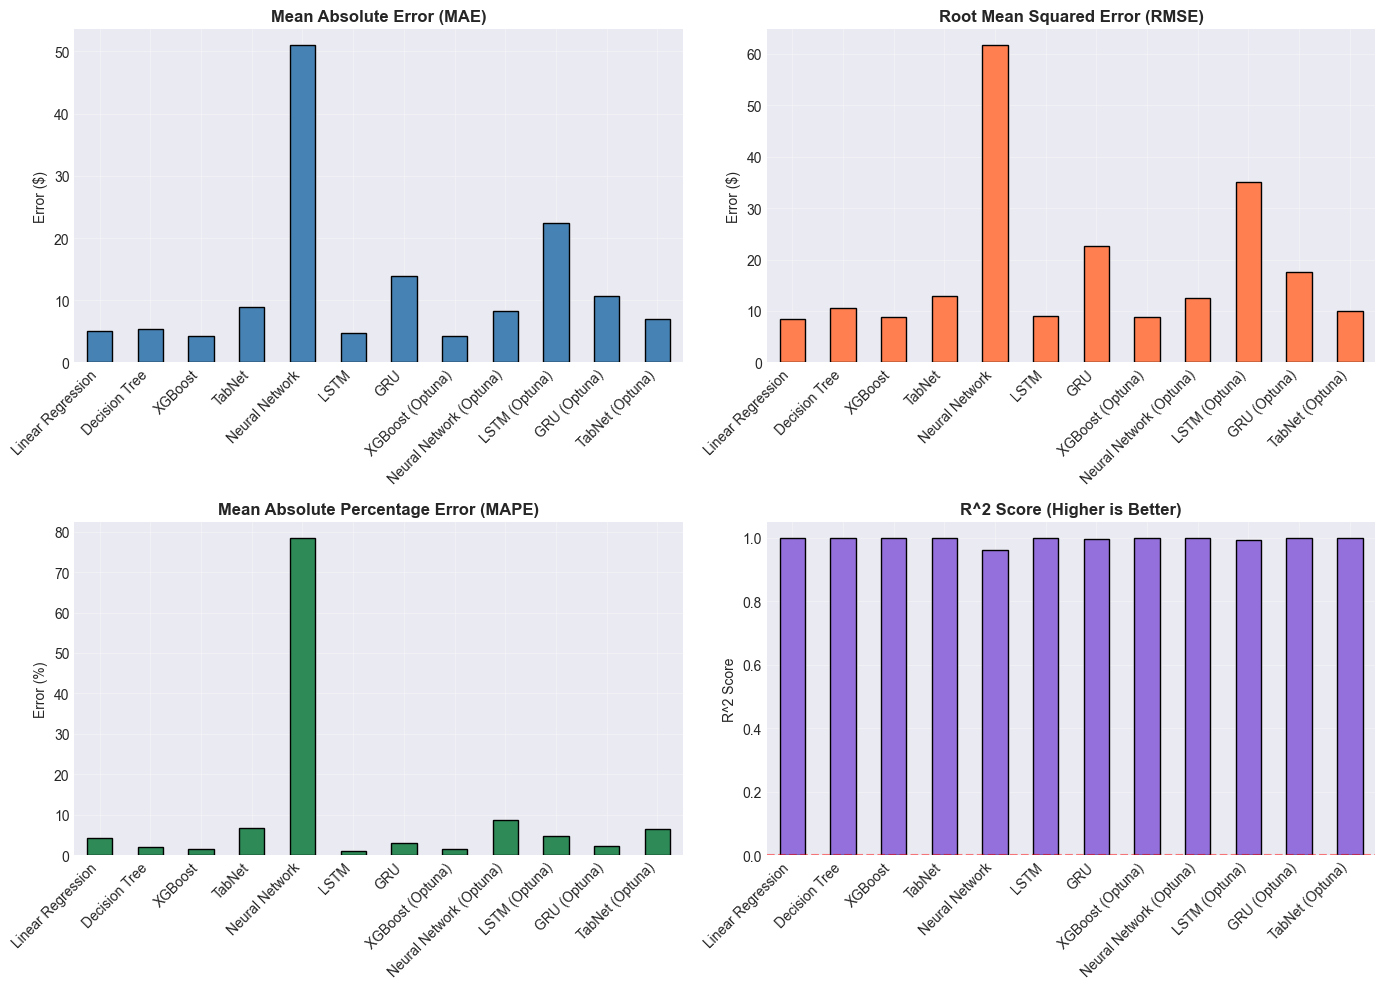


[OK] Saved: 03_regression_metrics_comparison.png


In [69]:
# Create metrics dataframe
metrics_df = pd.DataFrame({
    'MAE ($)': [results[name]['mae'] for name in results.keys()],
    'RMSE ($)': [results[name]['rmse'] for name in results.keys()],
    'MAPE (%)': [results[name]['mape']*100 for name in results.keys()],
    'R^2 Score': [results[name]['r2'] for name in results.keys()]
}, index=results.keys())

print("\n" + "="*70)
print("REGRESSION MODEL PERFORMANCE COMPARISON")
print("="*70)
print(metrics_df.round(4))

# Visualization: Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_df['MAE ($)'].plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Error ($)')
axes[0,0].grid(alpha=0.3)
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45, ha='right')

metrics_df['RMSE ($)'].plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='black')
axes[0,1].set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Error ($)')
axes[0,1].grid(alpha=0.3)
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45, ha='right')

metrics_df['MAPE (%)'].plot(kind='bar', ax=axes[1,0], color='seagreen', edgecolor='black')
axes[1,0].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Error (%)')
axes[1,0].grid(alpha=0.3)
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45, ha='right')

metrics_df['R^2 Score'].plot(kind='bar', ax=axes[1,1], color='mediumpurple', edgecolor='black')
axes[1,1].set_title('R^2 Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('R^2 Score')
axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1,1].grid(alpha=0.3)
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '03_regression_metrics_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n[OK] Saved: 03_regression_metrics_comparison.png")

## Step 7: Actual vs Predicted

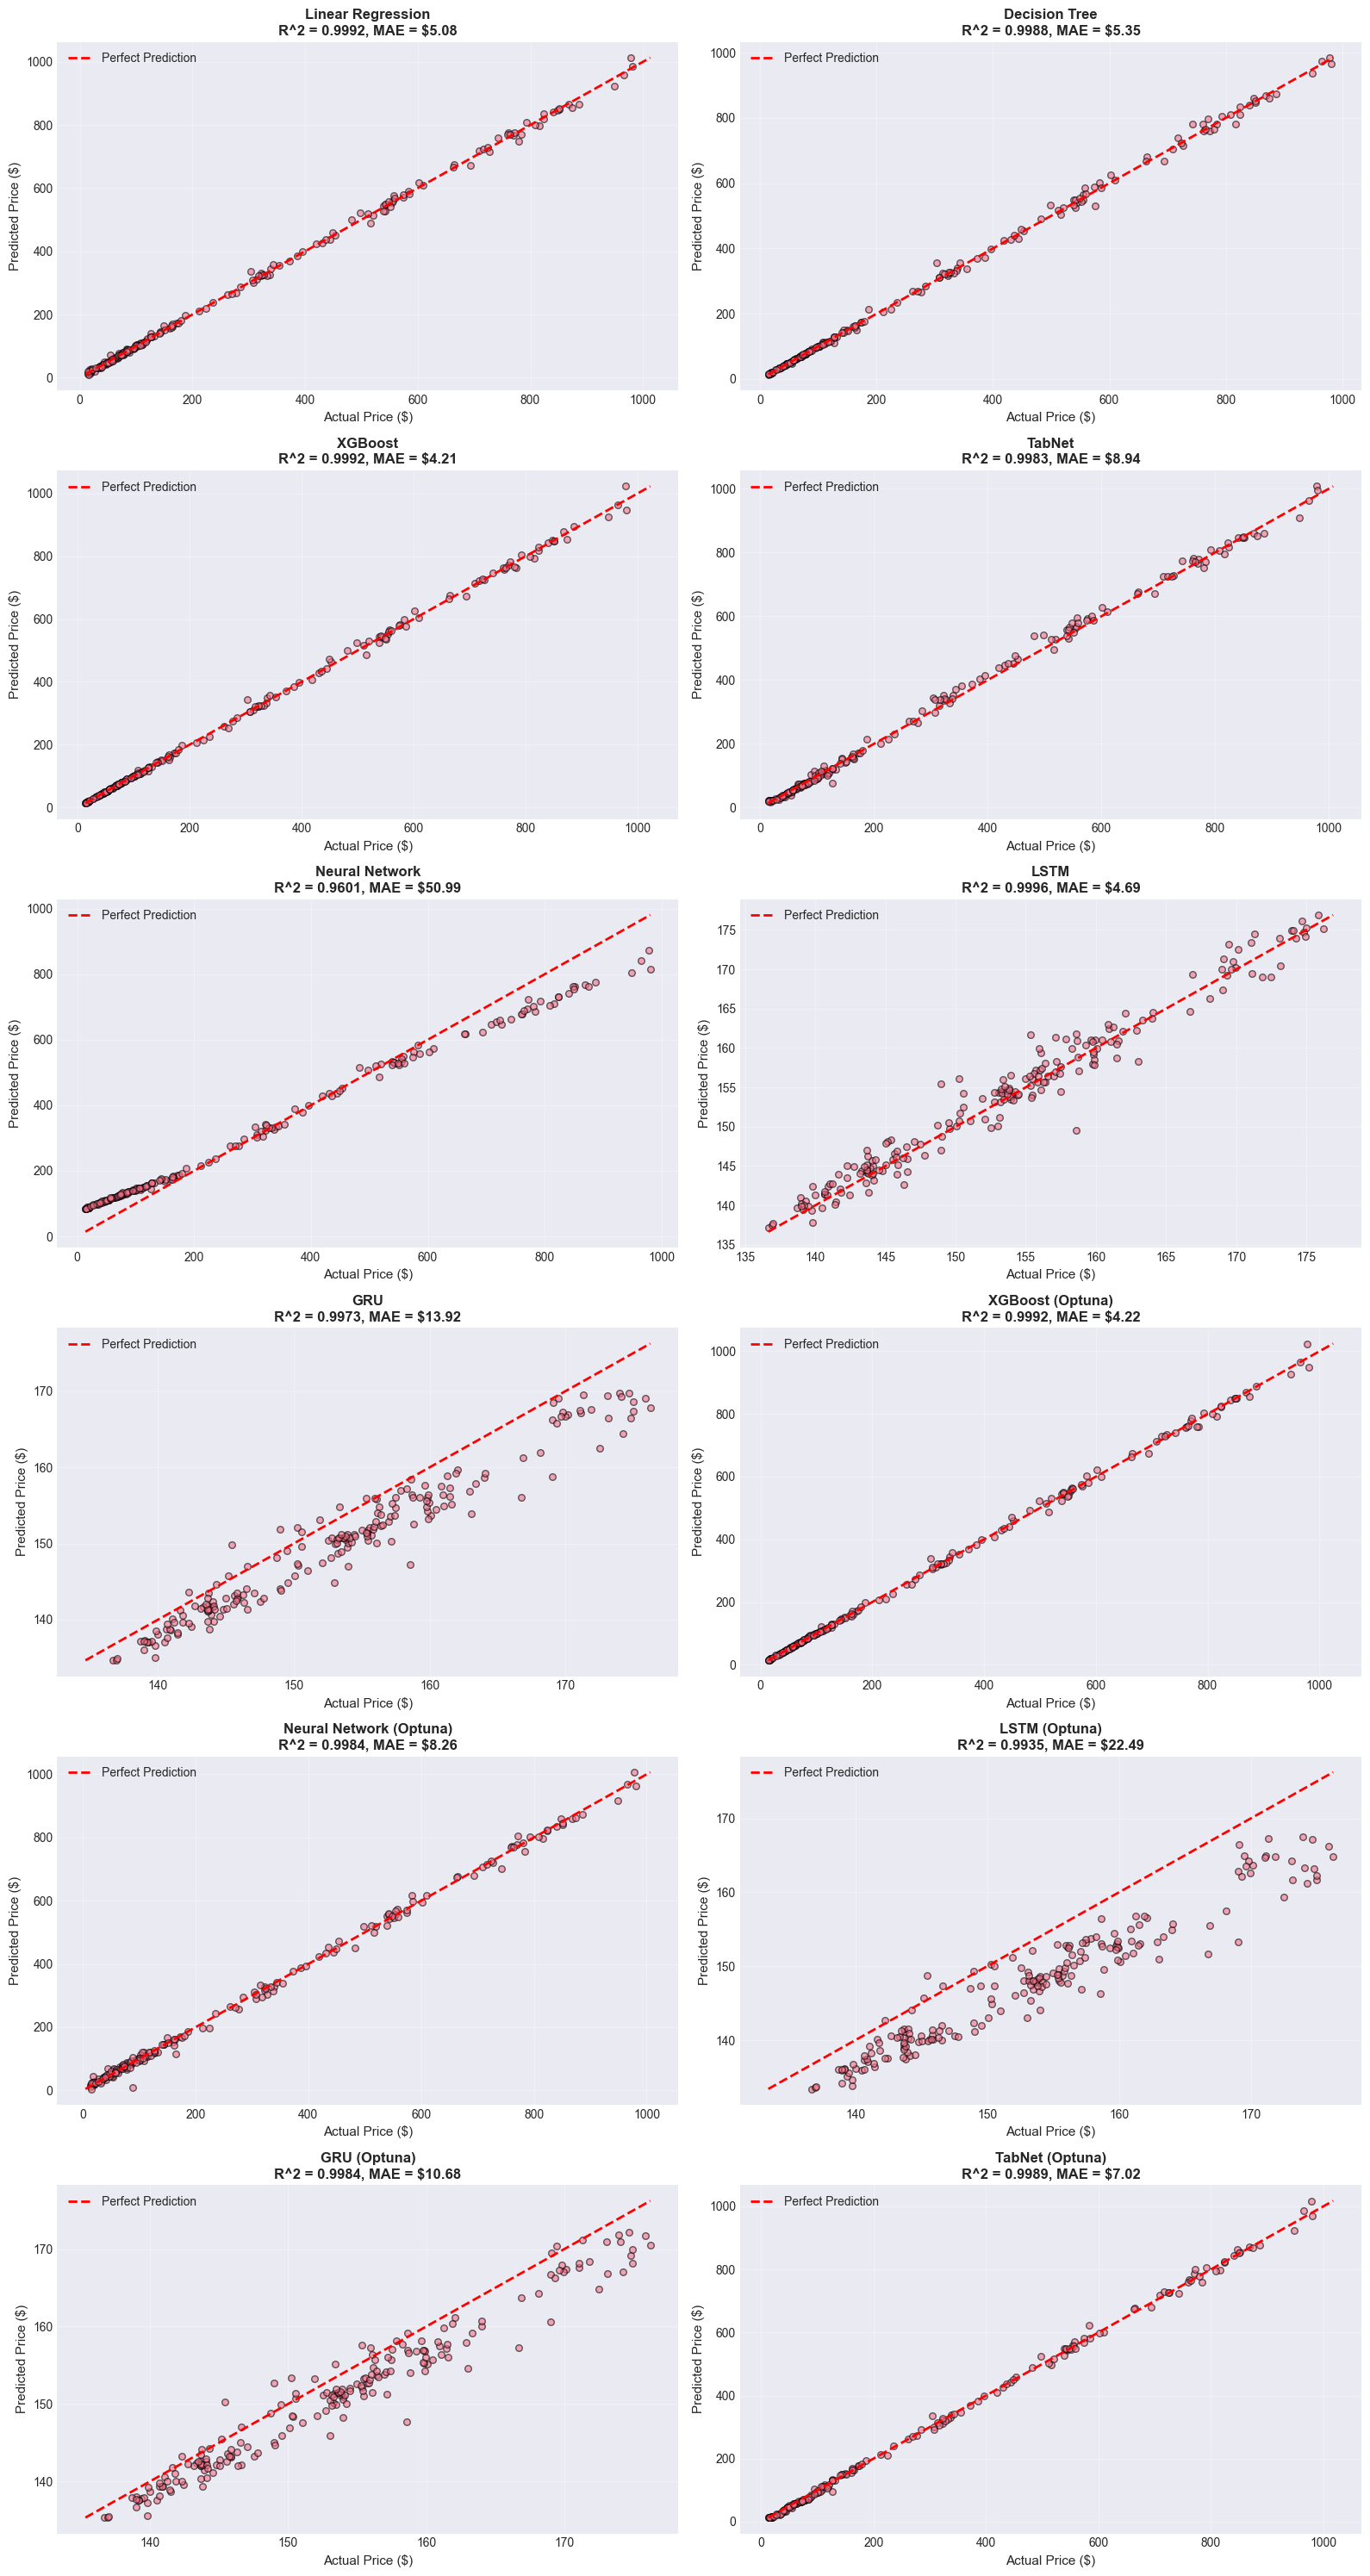

[OK] Saved: 04_actual_vs_predicted.png


In [70]:
n_models = len(results)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = np.array(axes).reshape(-1)

for idx, (name, result) in enumerate(results.items()):
    y_pred = np.ravel(result['y_pred'])
    if 'y_true' in result:
        y_true_plot = np.ravel(result['y_true'])
    else:
        y_true_plot = y_test.values

    sample_n = min(200, len(y_true_plot), len(y_pred))
    y_true_sample = y_true_plot[:sample_n]
    y_pred_sample = y_pred[:sample_n]

    axes[idx].scatter(y_true_sample, y_pred_sample, alpha=0.6, s=30, edgecolor='black')
    lims = [min(y_true_sample.min(), y_pred_sample.min()), max(y_true_sample.max(), y_pred_sample.max())]
    axes[idx].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
    axes[idx].set_xlabel('Actual Price ($)', fontsize=11)
    axes[idx].set_ylabel('Predicted Price ($)', fontsize=11)
    axes[idx].set_title(
        f"{name}\nR^2 = {result['r2']:.4f}, MAE = ${result['mae']:.2f}",
        fontsize=12, fontweight='bold'
    )
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

for j in range(n_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '04_actual_vs_predicted.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 04_actual_vs_predicted.png")

## Step 8: Residual Analysis

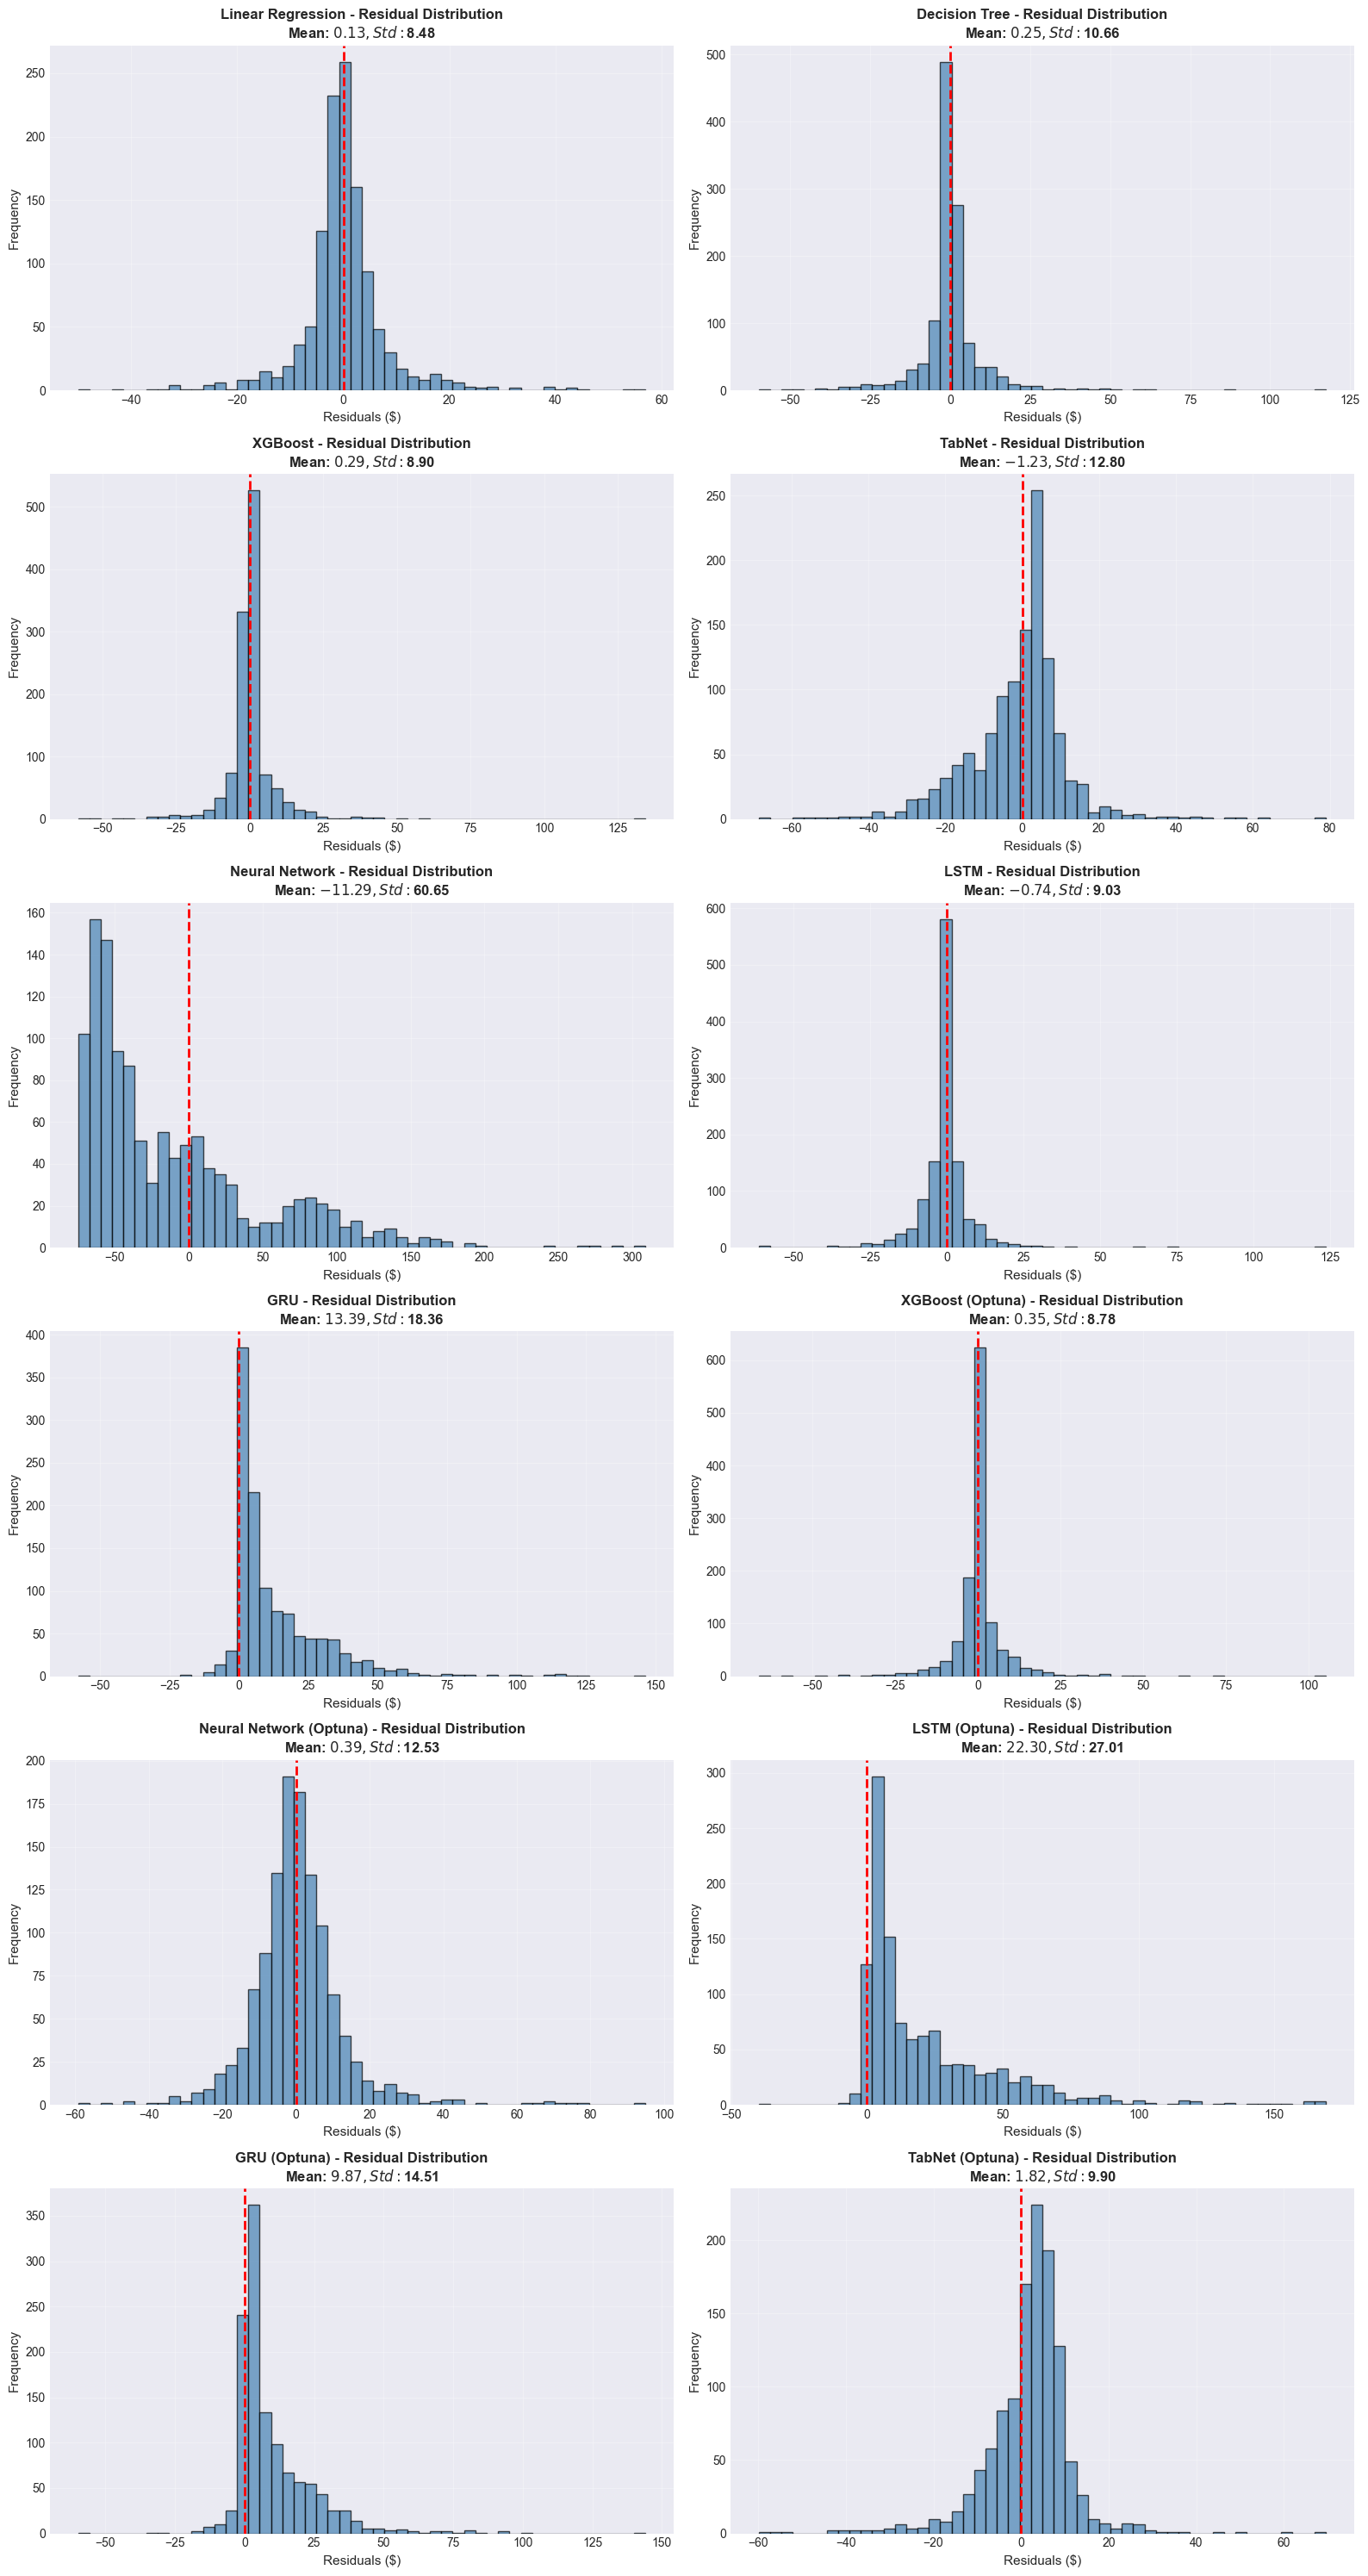

[OK] Saved: 05_residual_analysis.png


In [71]:
n_models = len(results)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = np.array(axes).reshape(-1)

for idx, (name, result) in enumerate(results.items()):
    y_pred = np.ravel(result['y_pred'])
    if 'y_true' in result:
        y_true_plot = np.ravel(result['y_true'])
    else:
        y_true_plot = y_test.values

    sample_n = min(len(y_true_plot), len(y_pred))
    residuals = y_true_plot[:sample_n] - y_pred[:sample_n]

    axes[idx].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_xlabel('Residuals ($)', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(
        f"{name} - Residual Distribution\nMean: ${residuals.mean():.2f}, Std: ${residuals.std():.2f}",
        fontsize=12, fontweight='bold'
    )
    axes[idx].grid(alpha=0.3)

for j in range(n_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '05_residual_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 05_residual_analysis.png")

## Step 9: Feature Importance

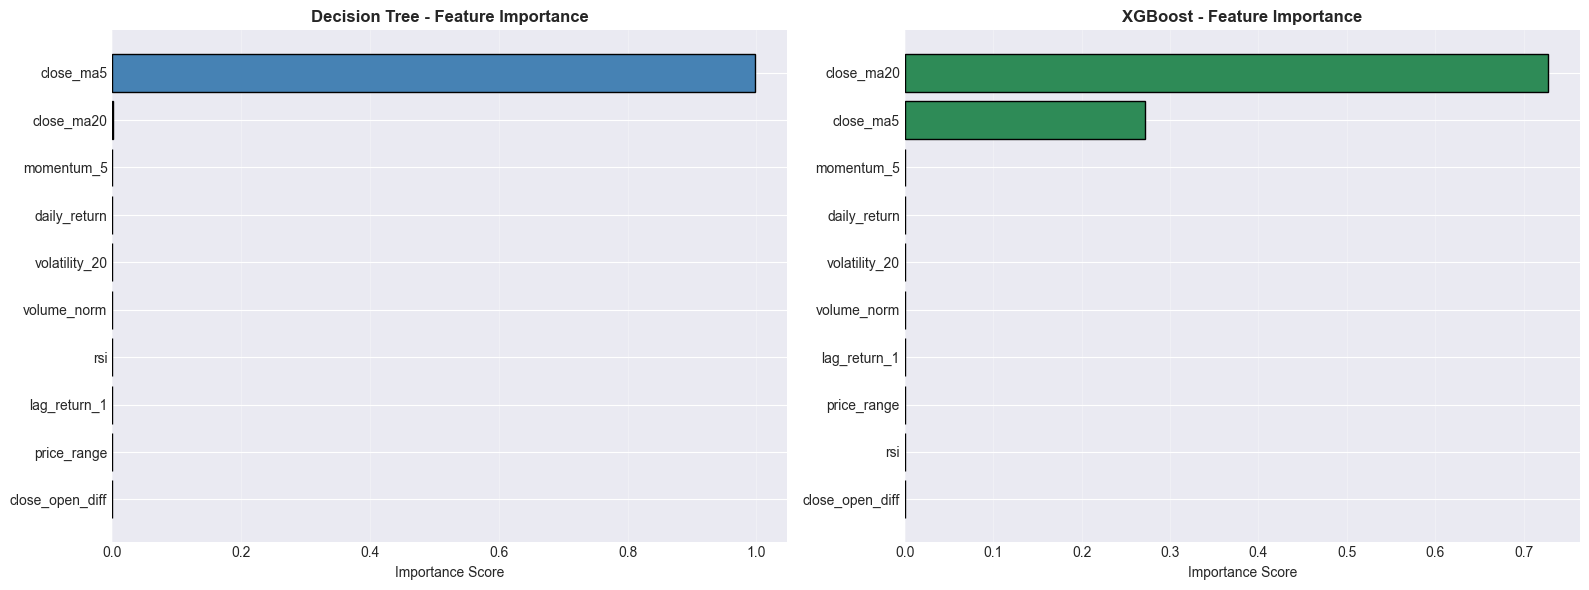

[OK] Saved: 06_feature_importance_regression.png


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decision Tree
dt_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': results['Decision Tree']['model'].feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(dt_importance['feature'], dt_importance['importance'], color='steelblue', edgecolor='black')
axes[0].set_title('Decision Tree - Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': results['XGBoost']['model'].feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(xgb_importance['feature'], xgb_importance['importance'], color='seagreen', edgecolor='black')
axes[1].set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '06_feature_importance_regression.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 06_feature_importance_regression.png")

## Step 10: Neural Network Training History

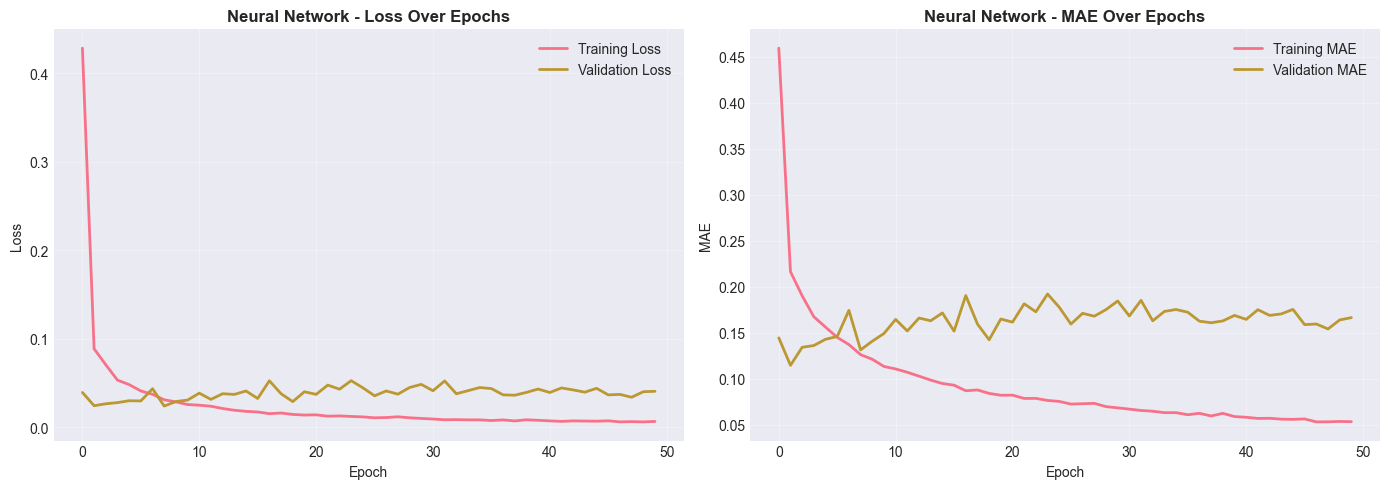

[OK] Saved: 07_nn_training_history.png


In [73]:
if 'history' in results['Neural Network']:
    history = results['Neural Network']['history']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Neural Network - Loss Over Epochs', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1].set_title('Neural Network - MAE Over Epochs', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(str(GRAPH_DIR / '07_nn_training_history.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("[OK] Saved: 07_nn_training_history.png")

## Step 11: Financial Analysis

In [74]:
best_model_name = min(results, key=lambda x: results[x]['mae'])
best_result = results[best_model_name]

print("\n" + "="*70)
print("REGRESSION MODEL - FINANCIAL TRADING ANALYSIS")
print("="*70)

print(f"\n[OK] BEST PERFORMING MODEL: {best_model_name}")
print(f"  |- MAE:   ${best_result['mae']:.2f}")
print(f"  |- RMSE:  ${best_result['rmse']:.2f}")
print(f"  |- MAPE:  {best_result['mape']:.4f} ({best_result['mape']*100:.2f}%)")
print(f"  `- R^2:   {best_result['r2']:.4f}")

print("\nPREDICTION ACCURACY INSIGHTS:")
avg_price = y_test.mean()
mae_percent = (best_result['mae'] / avg_price) * 100
print(f"  1. Average stock price: ${avg_price:.2f}")
print(f"  2. Mean prediction error: ${best_result['mae']:.2f} ({mae_percent:.2f}% of avg price)")
print(f"  3. Error stability (RMSE): {best_result['rmse']:.2f}")
print(f"  4. Explained variance (R^2): {best_result['r2']:.1%}")

print("\nTRADING STRATEGY IMPLICATIONS:")
if mae_percent < 2:
    print("  [OK] Excellent prediction accuracy (<2% error)")
elif mae_percent < 5:
    print("  [OK] Good prediction accuracy (2-5% error)")
else:
    print(f"  [WARN] Acceptable accuracy ({mae_percent:.1f}% error)")

print("\nRECOMMENDED TRADING APPROACH:")
print("  1. Use predictions as price targets, not entry signals")
print("  2. Trade when predicted price differs >2% from current price")
print("  3. Implement profit targets at predicted prices")
print("  4. Use prediction intervals (+/- 1 RMSE) as support/resistance")
print("  5. Monitor prediction accuracy daily")
print(f"  6. Consider prediction band: {avg_price - best_result['rmse']:.2f} to {avg_price + best_result['rmse']:.2f}")

print("\nRISK MANAGEMENT:")
print(f"  1. Prediction confidence interval: +/- ${best_result['rmse']:.2f}")
print(f"  2. Expected error range: +/- ${(best_result['mae']/avg_price)*100:.1f}%")
print("  3. Suggested max position size: 2-3% of capital per trade")
print(f"  4. Stop-loss recommendation: Beyond 2x RMSE ({best_result['rmse']*2:.2f})")


REGRESSION MODEL - FINANCIAL TRADING ANALYSIS

[OK] BEST PERFORMING MODEL: XGBoost
  |- MAE:   $4.21
  |- RMSE:  $8.91
  |- MAPE:  0.0160 (1.60%)
  `- R^2:   0.9992

PREDICTION ACCURACY INSIGHTS:
  1. Average stock price: $293.04
  2. Mean prediction error: $4.21 (1.44% of avg price)
  3. Error stability (RMSE): 8.91
  4. Explained variance (R^2): 99.9%

TRADING STRATEGY IMPLICATIONS:
  [OK] Excellent prediction accuracy (<2% error)

RECOMMENDED TRADING APPROACH:
  1. Use predictions as price targets, not entry signals
  2. Trade when predicted price differs >2% from current price
  3. Implement profit targets at predicted prices
  4. Use prediction intervals (+/- 1 RMSE) as support/resistance
  5. Monitor prediction accuracy daily
  6. Consider prediction band: 284.14 to 301.95

RISK MANAGEMENT:
  1. Prediction confidence interval: +/- $8.91
  2. Expected error range: +/- $1.4%
  3. Suggested max position size: 2-3% of capital per trade
  4. Stop-loss recommendation: Beyond 2x RMSE (

## Summary

### Regression Model Results:
- Successfully built and evaluated 7 regression models
- Added TabNet as a deep tabular baseline next to XGBoost
- Added Kaggle-style sequence baselines: LSTM and GRU (close-price windows)
- Added Optuna tuning workflow for XGBoost, TabNet, Dense NN, LSTM, and GRU
- Key metrics: MAE, RMSE, MAPE, R^2
- Models suitable for price targets in trading strategies

In [75]:
print('Part 2 model metrics:')
for k, v in results.items():
    print(k, {m: round(v[m], 4) for m in ['mae', 'rmse', 'mape', 'r2']})
print('Best by MAE:', min(results, key=lambda k: results[k]['mae']))

Part 2 model metrics:
Linear Regression {'mae': 5.0849, 'rmse': np.float64(8.4799), 'mape': 0.042, 'r2': 0.9992}
Decision Tree {'mae': 5.3512, 'rmse': np.float64(10.6675), 'mape': 0.0193, 'r2': 0.9988}
XGBoost {'mae': 4.2092, 'rmse': np.float64(8.9069), 'mape': 0.016, 'r2': 0.9992}
TabNet {'mae': 8.9415, 'rmse': np.float64(12.8636), 'mape': 0.0661, 'r2': 0.9983}
Neural Network {'mae': 50.9852, 'rmse': np.float64(61.6885), 'mape': 0.7845, 'r2': 0.9601}
LSTM {'mae': 4.6877, 'rmse': np.float64(9.0637), 'mape': 0.0108, 'r2': 0.9996}
GRU {'mae': 13.9211, 'rmse': np.float64(22.7227), 'mape': 0.0293, 'r2': 0.9973}
XGBoost (Optuna) {'mae': 4.2223, 'rmse': np.float64(8.7826), 'mape': 0.0162, 'r2': 0.9992}
Neural Network (Optuna) {'mae': 8.2581, 'rmse': np.float64(12.536), 'mape': 0.0875, 'r2': 0.9984}
LSTM (Optuna) {'mae': 22.4876, 'rmse': np.float64(35.0265), 'mape': 0.0472, 'r2': 0.9935}
GRU (Optuna) {'mae': 10.6848, 'rmse': np.float64(17.5541), 'mape': 0.0227, 'r2': 0.9984}
TabNet (Optuna) {